In [1]:
import pandas as pd
df=pd.read_csv('cars.csv')
print(df.info())


 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1725 entries, 0 to 1724
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Id                       1725 non-null   int64  
 1   year                     1725 non-null   int64  
 2   brand                    1725 non-null   object 
 3   full_model_name          1725 non-null   object 
 4   model_name               1725 non-null   object 
 5   price                    1725 non-null   float64
 6   distance_travelled(kms)  1725 non-null   float64
 7   fuel_type                1725 non-null   object 
 8   city                     1725 non-null   object 
 9   brand_rank               1725 non-null   int64  
 10  car_age                  1725 non-null   float64
dtypes: float64(3), int64(3), object(5)
memory usage: 148.4+ KB
None


In [1]:
df.isna ().sum()

NameError: name 'df' is not defined

In [19]:
df.duplicated().sum()

0

In [21]:
df_1=df[['year','brand','model_name','fuel_type','city','distance_travelled(kms)','brand_rank','car_age','price']]
#removed irrelavant ID, full_model name parameters
df_1=df

In [9]:
df_1

,Id,year,brand,full_model_name,model_name,price,distance_travelled(kms),fuel_type,city,brand_rank,car_age
0,0,2016,Honda,Honda Brio S MT,Brio,425000.0,9680.0,Petrol,Mumbai,7,5.0
1,1,2012,Nissan,Nissan Sunny XV Diesel,Sunny,325000.0,119120.0,Diesel,Mumbai,11,9.0
2,2,2017,Toyota,Toyota Fortuner 2.8 4x2 MT [2016-2020],Fortuner,2650000.0,64593.0,Diesel,Thane,1,4.0
3,3,2017,Mercedes-Benz,Mercedes-Benz E-Class E 220d Expression [2019-...,E-Class,4195000.0,25000.0,Diesel,Mumbai,2,4.0
4,4,2012,Hyundai,Hyundai Verna Fluidic 1.6 CRDi SX,Verna,475000.0,23800.0,Diesel,Mumbai,14,9.0
...,...,...,...,...,...,...,...,...,...,...,...
1720,1720,2015,Hyundai,Hyundai Eon Era +,Eon,290000.0,38000.0,Petrol,Pune,14,6.0
1721,1721,2011,Bentley,Bentley Continental Flying Spur W12,Continental,7500000.0,36000.0,Petrol,Pune,44,10.0
1722,1722,2008,Mahindra-Renault,Mahindra-Renault Logan DLE 1.5 dci,Logan,185000.0,142522.0,Diesel,Pune,24,13.0
1723,1723,1990,Mahindra,Mahindra Jeep CJ 500 D,Jeep,325000.0,18581.0,Diesel,Pune,24,31.0


In [23]:
df_1.isnull().sum() # check if any columns are null


Id                         0
year                       0
brand                      0
full_model_name            0
model_name                 0
price                      0
distance_travelled(kms)    0
fuel_type                  0
city                       0
brand_rank                 0
car_age                    0
dtype: int64

In [25]:
df_1.head(3)
df_1.tail(3)

,Id,year,brand,full_model_name,model_name,price,distance_travelled(kms),fuel_type,city,brand_rank,car_age
1722,1722,2008,Mahindra-Renault,Mahindra-Renault Logan DLE 1.5 dci,Logan,185000.0,142522.0,Diesel,Pune,24,13.0
1723,1723,1990,Mahindra,Mahindra Jeep CJ 500 D,Jeep,325000.0,18581.0,Diesel,Pune,24,31.0
1724,1724,2017,Hyundai,Hyundai Creta SX Plus 1.6 AT CRDI,Creta,1395000.0,31028.0,Diesel,Pune,14,4.0


In [29]:
# DATA PREPROCESSING ()
# Label Encoding
from sklearn import preprocessing
label_encoder = preprocessing.LabelEncoder()
df_2 = df_1
df_2['brand']= label_encoder.fit_transform(df_2['brand'])
df_2['model_name']= label_encoder.fit_transform(df_2['model_name'])
df_2['city']= label_encoder.fit_transform(df_2['city'])
df_2['fuel_type']= label_encoder.fit_transform(df_2['fuel_type'])
df_2['full_model_name']= label_encoder.fit_transform(df_2['full_model_name'])

df_2

,Id,year,brand,full_model_name,model_name,price,distance_travelled(kms),fuel_type,city,brand_rank,car_age
0,0,2016,7,131,28,425000.0,9680.0,3,9,7,5.0
1,1,2012,23,570,129,325000.0,119120.0,1,9,11,9.0
2,2,2017,28,676,69,2650000.0,64593.0,1,14,1,4.0
3,3,2017,21,526,51,4195000.0,25000.0,1,9,2,4.0
4,4,2012,8,259,144,475000.0,23800.0,1,9,14,9.0
...,...,...,...,...,...,...,...,...,...,...,...
1720,1720,2015,8,221,59,290000.0,38000.0,3,13,14,6.0
1721,1721,2011,2,80,41,7500000.0,36000.0,3,13,44,10.0
1722,1722,2008,19,391,96,185000.0,142522.0,1,13,24,13.0
1723,1723,1990,18,347,89,325000.0,18581.0,1,13,24,31.0


In [31]:
# variance comparison
df_2.var()

Id                         2.481125e+05
year                       1.028808e+01
brand                      8.461353e+01
full_model_name            4.718125e+04
model_name                 2.392481e+03
price                      2.794440e+12
distance_travelled(kms)    2.000374e+09
fuel_type                  1.017958e+00
city                       1.874791e+01
brand_rank                 1.677315e+02
car_age                    1.028808e+01
dtype: float64

In [33]:
df_2.corr()

,Id,year,brand,full_model_name,model_name,price,distance_travelled(kms),fuel_type,city,brand_rank,car_age
Id,1.000000,-0.054391,0.038418,0.033483,0.020867,-0.105696,0.100282,-0.078581,0.122431,0.022191,0.054391
year,-0.054391,1.000000,0.031594,0.015058,0.016492,0.288483,-0.386107,-0.062748,-0.158838,0.134275,-1.000000
brand,0.038418,0.031594,1.000000,0.983638,0.171926,-0.112988,0.083600,-0.015952,0.054782,0.175707,-0.031594
full_model_name,0.033483,0.015058,0.983638,1.000000,0.250601,-0.079232,0.086850,-0.017261,0.050820,0.112479,-0.015058
model_name,0.020867,0.016492,0.171926,0.250601,1.000000,-0.082217,0.036930,-0.014848,-0.010279,0.188761,-0.016492
price,-0.105696,0.288483,-0.112988,-0.079232,-0.082217,1.000000,-0.137351,-0.259728,-0.082369,-0.164591,-0.288483
distance_travelled(kms),0.100282,-0.386107,0.083600,0.086850,0.036930,-0.137351,1.000000,-0.232681,0.090316,-0.111406,0.386107
fuel_type,-0.078581,-0.062748,-0.015952,-0.017261,-0.014848,-0.259728,-0.232681,1.000000,-0.009624,0.128372,0.062748
city,0.122431,-0.158838,0.054782,0.050820,-0.010279,-0.082369,0.090316,-0.009624,1.000000,0.060534,0.158838
brand_rank,0.022191,0.134275,0.175707,0.112479,0.188761,-0.164591,-0.111406,0.128372,0.060534,1.000000,-0.134275


In [49]:
#'year','brand','model_name','fuel_type','city','distance_travelled(kms)','brand_rank','car_age','price'
#numeric = df_2[['year','brand','model_name','fuel_type','city','distance_travelled(kms)','brand_rank','car_age']]
numeric = df_2
#df_2.drop(['item_visibility'],inplace=True)
var = numeric.var()
numeric = numeric.columns
variable = [ ]
variable_rem = [ ]

for i in range(0,len(var)):
    if var[i]>=10:   #setting the threshold as 10%  ,
       variable.append(numeric[i])
    else:
       variable_rem.append(numeric[i])


/tmp/ipykernel_4809/3315997960.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if var[i]>=10:   #setting the threshold as 10%  ,


In [101]:
#df_2.drop('Id',inplace=True,axis=1)
df_2

,brand,model_name,full_model_name,city,distance_travelled(kms),brand_rank,car_age,price
0,7,28,131,9,9680.0,7,5.0,425000.0
1,23,129,570,9,119120.0,11,9.0,325000.0
2,28,69,676,14,64593.0,1,4.0,2650000.0
3,21,51,526,9,25000.0,2,4.0,4195000.0
4,8,144,259,9,23800.0,14,9.0,475000.0
...,...,...,...,...,...,...,...,...
1720,8,59,221,13,38000.0,14,6.0,290000.0
1721,2,41,80,13,36000.0,44,10.0,7500000.0
1722,19,96,391,13,142522.0,24,13.0,185000.0
1723,18,89,347,13,18581.0,24,31.0,325000.0


In [55]:
variable_rem

['fuel_type']

In [158]:
print([v for v in variable])
df_2=df_2[['brand', 'full_model_name', 'model_name', 'price', 'distance_travelled(kms)', 'city', 'brand_rank', 'car_age']]
df_2

['Id', 'year', 'brand', 'full_model_name', 'model_name', 'price', 'distance_travelled(kms)', 'city', 'brand_rank', 'car_age']


,brand,full_model_name,model_name,price,distance_travelled(kms),city,brand_rank,car_age
0,7,131,28,425000.0,9680.0,9,7,5.0
1,23,570,129,325000.0,119120.0,9,11,9.0
2,28,676,69,2650000.0,64593.0,14,1,4.0
3,21,526,51,4195000.0,25000.0,9,2,4.0
4,8,259,144,475000.0,23800.0,9,14,9.0
...,...,...,...,...,...,...,...,...
1720,8,221,59,290000.0,38000.0,13,14,6.0
1721,2,80,41,7500000.0,36000.0,13,44,10.0
1722,19,391,96,185000.0,142522.0,13,24,13.0
1723,18,347,89,325000.0,18581.0,13,24,31.0


# DATA  VISUALIZATION


In [35]:
import seaborn as sns
import matplotlib.pyplot as plt



<BarContainer object of 1725 artists>

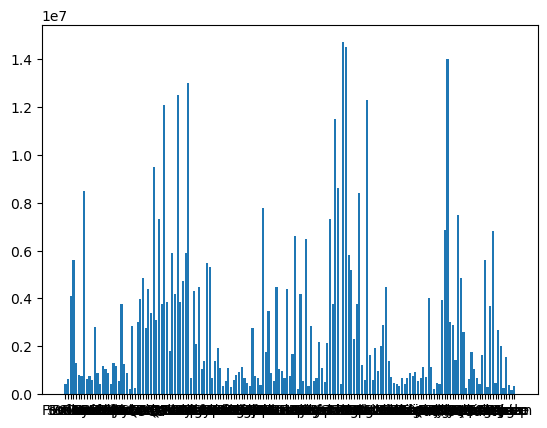

In [37]:
#sns.barplot(df['model_name'],df['price'])

plt.bar(df['model_name'],df['price'])

In [22]:
plt.show()

NameError: name 'plt' is not defined

In [ ]:
# Histogram for price distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], kde=True, bins=30)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()


In [67]:
# DATA TRAIN TEST SPLIT

# DATA PREPROCESSING ()

# Seperate the features and Target dataset
X= df_2.drop(['price'] , axis = 1)
Y = df_2[['price']]



# Split the data
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


In [97]:

print("\nRandom Forest Results:")

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=150, random_state=42,max_depth=15)
rf_model.fit(X_train, Y_train)
rf_predictions = rf_model.predict(X_test)
print("\nRandom Forest Results:")

from sklearn.metrics import mean_squared_error, r2_score
print("\nRandom Forest Results:")

print("R2 Score: ",r2_score(Y_test, rf_predictions))
import numpy as np

print("RMSE",mean_squared_error(Y_test, rf_predictions))




Random Forest Results:


/home/admin1/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)



Random Forest Results:

Random Forest Results:
R2 Score:  0.7142054145486652
RMSE 959416395200.137


In [139]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=200, random_state=42,max_depth=15,min_samples_split=2,max_features=['auto'])
rf_model.fit(X_train, Y_train)
rf_predictions = rf_model.predict(X_test)
print("\nRandom Forest Results:::")


InvalidParameterError: The 'max_features' parameter of RandomForestRegressor must be an int in the range [1, inf), a float in the range (0.0, 1.0], a str among {'log2', 'sqrt'} or None. Got ['auto'] instead.

In [141]:
from sklearn.metrics import mean_squared_error, r2_score
print("\nRandom Forest Results:")

print("R2 Score: ",r2_score(Y_test, rf_predictions))



Random Forest Results:
R2 Score:  0.7148397643127395


In [117]:
import numpy as np

print("RMSE",mean_squared_error(Y_test, rf_predictions))


RMSE 1727699735640.9407


In [66]:
# Feature importance for Random Forest
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)
print("\nFeature Importance:")
print(feature_importance)



Feature Importance:
                   feature  importance
1                    brand    0.246799
6               brand_rank    0.232595
2               model_name    0.163139
7                  car_age    0.107525
5  distance_travelled(kms)    0.105354
0                     year    0.092649
4                     city    0.028606
3                fuel_type    0.023333


In [71]:
#Standardization

from sklearn.preprocessing import StandardScaler

sc=StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)

In [73]:
# lets determine the Value of N-Components
from sklearn.decomposition import PCA

# Lets create the PCA Model
pca = PCA(n_components = None)
x_train_pca = pca.fit_transform(X_train)
x_test_pca = pca.transform(X_test)

# This result the variance explained by the number of components taken into account
pca.explained_variance_ratio_.cumsum()  # To find which one is the optimal Compoment 

array([0.99999883, 0.99999988, 0.99999995, 0.99999999, 1.        ,
       1.        ])

In [75]:
from sklearn.decomposition import PCA

pca=PCA(n_components=2)
x_train_pca = pca.fit_transform(X_train)
x_test_pca = pca.transform(X_test)

In [77]:
#This result the variance explained by the number of components taken into account

pca.explained_variance_ratio_.cumsum()

array([0.99999883, 0.99999988])

In [79]:
x_train_pca

array([[ 3.60468465e+04,  2.52205498e+00],
       [-1.79671561e+04, -3.71367431e+01],
       [-4.24531527e+04,  5.10342098e+01],
       ...,
       [ 2.00468423e+04, -7.42922783e+01],
       [-3.93531561e+04, -5.14385946e+01],
       [ 2.63428466e+04,  2.54375955e+01]])

In [83]:
df=pd.DataFrame({'x_train_pca0':x_train_pca[:,0],'x_train_pca1':x_train_pca[:,1],'Species':Y_train})

ValueError: Data must be 1-dimensional, got ndarray of shape (1380, 1) instead